In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt

In [3]:
import crosscoders as xc
import torch


------------------------- CONSTANTS -------------------------
GlobalsConfig(
    PROJECT_ROOT_DIR = '/home/ec2-user/crosscoders',
    CONFIG_FILEPATH = '/home/ec2-user/crosscoders/src/scripts/configs/train.yml',
    DATA_DIR = '/home/ec2-user/crosscoders/data',
    EXPERIMENT = ExperimentConfig(
        BATCH_SIZE = 8192,
        MAX_RECORDS = None,
        MAX_BATCHES = 1000000,
        MAX_TOKENS = 2000000,
        NUM_GPUS = 1,
        NUM_TRAINERS = 1,
        HARDWARE = HardwareConfig(
            dtype = torch.float32,
            device = 'cuda',
        ),
    ),
)
-------------------------------------------------------------



In [4]:
# from crosscoders.autoencoders.acausal.model import JumpReLUFunction


# JumpReLUFunction()

In [5]:

from crosscoders.constants import CONSTANTS
from crosscoders.dataclasses.configs.runner import RunnerConfig
from crosscoders.utils import from_dict, get_config


runner_cfg = from_dict(
    RunnerConfig,
    get_config(CONSTANTS.CONFIG_FILEPATH).get('RUNNER', {})
)
runner_cfg

RunnerConfig(
    MODEL = ModelConfig(
        CAUSALITY = 'acausal',
        LOCALITY = 'global',
        ACTIVATION_FUNCTION = 'jumprelu',
        eps = 2,
        N_LAYERS = 12,
        D_MODEL = 768,
        D_CODER = 16384,
        HARDWARE = HardwareConfig(
            dtype = torch.float32,
            device = 'cuda',
        ),
    ),
    LOSS = LossConfig(
        c = 4,
        lambda_s = 10,
        lambda_p = 3e-06,
    ),
    OPTIMIZER = OptimizerConfig(
        optimizer = <class 'torch.optim.adam.Adam'>,
        parameters = OptimizerParameters(
            lr = 0.0004,
            betas = (0.9, 0.999),
            fused = True,
        ),
    ),
)

In [6]:
from crosscoders.autoencoders.acausal.runner import AcausalAutoencoderRunner


runner = AcausalAutoencoderRunner(runner_cfg)

In [36]:
CONSTANTS.EXPERIMENT.MAX_TOKENS = 2000000

In [38]:
from crosscoders.data.dataset import TinyStoriesRayDataset


# activations_ds = TinyStoriesRayDataset('monology/pile-uncopyrighted').load('activations')
activations_ds = TinyStoriesRayDataset().load('activations')

Metadata Fetch Progress 0:   0%|          | 0.00/265 [00:00<?, ? task/s]

Parquet Files Sample 0:   0%|          | 0.00/10.0 [00:00<?, ? file/s]

In [9]:
# train_ds.write_parquet(
#             '/home/ec2-user/crosscoders/data/input/roneneldan/TinyStories/train',
#             compression='LZ4',
#             concurrency=6,
#             ray_remote_args={
#                 'num_cpus': 1
#             },
#         )

In [26]:
train_dl = train_ds.iter_torch_batches(
    batch_size=CONSTANTS.EXPERIMENT.BATCH_SIZE,
    # local_shuffle_buffer_size=16
    device='cuda'
)

for batch_idx, batch in enumerate(train_dl):

    # loss = runner.training_step(batch)

    # print(loss)

    break

2025-02-19 02:42:28,267	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2025-02-19_00-59-16_117430_16444/logs/ray-data
2025-02-19 02:42:28,268	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> LimitOperator[limit=1000000]


Running 0: 0.00 row [00:00, ? row/s]

- ReadParquet 1: 0.00 row [00:00, ? row/s]

- limit=1000000 2: 0.00 row [00:00, ? row/s]

In [28]:
x = batch['resid_post']

x_hat = model(x)

In [ ]:
model.x_enc

tensor(True, device='cuda:0')

In [30]:
(x_hat - x).pow(2).sum((-2, -1)).mean()

tensor(85765.6094, device='cuda:0', grad_fn=<MeanBackward0>)

In [13]:
x.shape

torch.Size([1000, 12, 768])

In [16]:
x.norm(dim=-1)

torch.Size([1000, 12])

In [14]:
import numpy as np

np.sqrt(runner_cfg.MODEL.D_MODEL)

27.712812921102035

In [31]:
train_ds

limit=1000000
+- Dataset(
      num_rows=1924184,
      schema={resid_post: numpy.ndarray(shape=(12, 768), dtype=float)}
   )

In [33]:
# def get_scalar(batch):

#     batch['resid_post_norm_sum'] = [np.linalg.norm(batch['resid_post'], ord=2, axis=-1).sum()]
#     # batch['resid_post_norm_count'] = batch['resid_post'].shape[0] * batch['resid_post'].shape[1]
#     batch['resid_post_norm_count'] = [batch['resid_post'].shape[0] * batch['resid_post'].shape[1]]

#     del batch['resid_post']

#     # raise NotImplementedError(batch)

#     return batch

# stats = train_ds.map_batches(get_scalar).sum()

2025-02-14 19:50:52,183	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2025-02-14_18-52-24_879061_2856/logs/ray-data
2025-02-14 19:50:52,183	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> LimitOperator[limit=1000000] -> TaskPoolMapOperator[MapBatches(get_scalar)] -> LimitOperator[limit=1]


Running 0: 0.00 row [00:00, ? row/s]

- ReadParquet->SplitBlocks(2) 1: 0.00 row [00:00, ? row/s]

- limit=1000000 2: 0.00 row [00:00, ? row/s]

- MapBatches(get_scalar) 3: 0.00 row [00:00, ? row/s]

...

- Aggregate 4: 0.00 row [00:00, ? row/s]

Sort Sample 5:   0%|          | 0.00/1.00 [00:00<?, ? row/s]

Shuffle Map 6:   0%|          | 0.00/1.00 [00:00<?, ? row/s]

Shuffle Reduce 7:   0%|          | 0.00/1.00 [00:00<?, ? row/s]

- limit=1 8: 0.00 row [00:00, ? row/s]

140.60230497021485

In [41]:
# scaled_model_dim = np.sqrt(runner_cfg.MODEL.D_MODEL)
# x_mean_l2 = stats['sum(resid_post_norm_sum)'] / stats['sum(resid_post_norm_count)']

# X_SCALAR = np.sqrt(runner_cfg.MODEL.D_MODEL) / x_mean_l2

# scaled_model_dim, x_mean_l2, X_SCALAR

(27.712812921102035, 140.60230497021485, 0.19710070135032787)

In [16]:
activations_ds

limit=2000000
+- Dataset(
      num_rows=187446,
      schema={
         tokens: float,
         gpt2-small.resid_post: numpy.ndarray(shape=(12, 768), dtype=float),
         gpt-neo-125M.resid_post: numpy.ndarray(shape=(12, 768), dtype=float)
      }
   )

['gpt2-small', 'gpt-neo-125M']

In [22]:
import numpy as np

In [39]:
import numpy as np

def get_x_scalar(ds, runner_cfg):

    def get_batch_expected_norm(batch):

        stats = {}

        for k in batch:
            if k != 'tokens':
                stats[f'{k}.sum'] = [np.linalg.norm(batch[k], ord=2, axis=-1).sum()]
                stats[f'{k}.count'] = [batch[k].shape[0] * batch[k].shape[1]]

        return stats


    stats = ds.map_batches(get_batch_expected_norm, zero_copy_batch=True).sum()
    # model_names = [c.split('.')]


    scaled_model_dim = np.sqrt(runner_cfg.MODEL.D_MODEL)


    # return {scaled_model_dim / (stats[f'sum({mn[0]}.{mn[1]}.sum)'] / stats[f'sum({mn[0]}.{mn[1]}.count)']) for mn in model_names}
    return {c: scaled_model_dim / (stats[f'sum({c}.sum)'] / stats[f'sum({c}.count)']) for c in ds.columns() if c != 'tokens'}

    # x_mean_l2 = stats['sum(resid_post_norm_sum)'] / stats['sum(resid_post_norm_count)']

    # X_SCALAR = scaled_model_dim / x_mean_l2

    # return scaled_model_dim, x_mean_l2, X_SCALAR



stats = get_x_scalar(activations_ds, runner_cfg)

2025-02-21 17:03:33,015	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2025-02-21_16-15-45_954272_3931/logs/ray-data
2025-02-21 17:03:33,016	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> LimitOperator[limit=2000000] -> TaskPoolMapOperator[MapBatches(get_batch_expected_norm)] -> LimitOperator[limit=1]


Running 0: 0.00 row [00:00, ? row/s]

- ReadParquet->SplitBlocks(2) 1: 0.00 row [00:00, ? row/s]

- limit=2000000 2: 0.00 row [00:00, ? row/s]

- MapBatches(get_batch_expected_norm) 3: 0.00 row [00:00, ? row/s]

...

Sort Sample 5:   0%|          | 0.00/1.00 [00:00<?, ? row/s]

Shuffle Map 6:   0%|          | 0.00/1.00 [00:00<?, ? row/s]

Shuffle Reduce 7:   0%|          | 0.00/1.00 [00:00<?, ? row/s]

- limit=1 8: 0.00 row [00:00, ? row/s]

KeyboardInterrupt: 

In [42]:
import boto3, json

content_object = boto3.resource('s3').Object('crosscoders', 'input/roneneldan/TinyStories/stats-3M.json')
file_content = content_object.get()['Body'].read().decode('utf-8')
stats = json.loads(file_content)
print(stats)


# import boto3, json
# s3object = boto3.resource('s3').Object('crosscoders', 'input/roneneldan/TinyStories/stats-3M.json')

# s3object.put(
#     Body=(bytes(json.dumps(stats).encode('UTF-8')))
# )

{'gpt2-small.resid_post': 0.21570403085908926, 'gpt-neo-125M.resid_post': 0.02157010092209927}


In [29]:
stats

{'gpt2-small.resid_post': 0.2166239480068761,
 'gpt-neo-125M.resid_post': 0.02162264361958447}

In [ ]:
# def scale_x(batch, X_SCALAR):

#     batch['resid_post'] = X_SCALAR * batch['resid_post']

#     return batch


# train_ds_scaled = activations_ds.map_batches(scale_x, X_SCALAR=X_SCALAR, batch_size=CONSTANTS.EXPERIMENT.BATCH_SIZE)

In [43]:
activations_ds.select_columns('gpt2-small.resid_post').rename_columns(['resid_post'])

2025-02-21 17:36:47,717	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2025-02-21_16-15-45_954272_3931/logs/ray-data
2025-02-21 17:36:47,718	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> LimitOperator[limit=2000000] -> TaskPoolMapOperator[Project] -> LimitOperator[limit=1]


Running 0: 0.00 row [00:00, ? row/s]

- ReadParquet->SplitBlocks(2) 1: 0.00 row [00:00, ? row/s]

- limit=2000000 2: 0.00 row [00:00, ? row/s]

- Project 3: 0.00 row [00:00, ? row/s]

- limit=1 4: 0.00 row [00:00, ? row/s]

Project
+- Project
   +- limit=2000000
      +- Dataset(
            num_rows=3000000,
            schema={
               tokens: float,
               gpt2-small.resid_...: numpy.ndarray(shape=(12, 768), dtype=float),
               gpt-neo-125M.resi...: numpy.ndarray(shape=(12, 768), dtype=float)
            }
         )

In [15]:
10 // 3

3

In [ ]:
# from src.scripts import train


# train.main()

In [44]:
import ray, ray.train
from ray.train.torch import TorchTrainer

from scripts.train import train_loop_per_worker



trainer = TorchTrainer(
    ray.tune.with_parameters(train_loop_per_worker, X_SCALAR=stats['gpt2-small.resid_post']),
    # train_loop_config=ExperimentConfig(),
    # train_loop_config={
    #     # 'OPTIMIZER': {'parameters': {'lr': }}
    #     'LOSS': {'lambda_s': 0.1}
    # },
    scaling_config=ray.train.ScalingConfig(
        num_workers=CONSTANTS.EXPERIMENT.NUM_TRAINERS,
        use_gpu=True,
        resources_per_worker={'CPU': 1, 'GPU': 1}
    ),
    run_config = ray.train.RunConfig(
        # checkpoint_config=ray.train.CheckpointConfig(num_to_keep=1),
        storage_path='s3://crosscoders/ray/jumprelu/uniform_init/trained/pile'
    ),
    datasets={'train': activations_ds.select_columns('gpt2-small.resid_post').rename_columns(['resid_post'])}
)
result: ray.train.Result = trainer.fit()


2025-02-21 17:37:13,589	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2025-02-21_16-15-45_954272_3931/logs/ray-data
2025-02-21 17:37:13,589	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> LimitOperator[limit=2000000] -> TaskPoolMapOperator[Project] -> LimitOperator[limit=1]


Running 0: 0.00 row [00:00, ? row/s]

- ReadParquet->SplitBlocks(2) 1: 0.00 row [00:00, ? row/s]

- limit=2000000 2: 0.00 row [00:00, ? row/s]

- Project 3: 0.00 row [00:00, ? row/s]

...

2025-02-21 17:38:56,414	ERROR tune_controller.py:1331 -- Trial task failed for trial TorchTrainer_80aec_00000
Traceback (most recent call last):
  File "/home/ec2-user/crosscoders/.conda/lib/python3.12/site-packages/ray/air/execution/_internal/event_manager.py", line 110, in resolve_future
    result = ray.get(future)
             ^^^^^^^^^^^^^^^
  File "/home/ec2-user/crosscoders/.conda/lib/python3.12/site-packages/ray/_private/auto_init_hook.py", line 21, in auto_init_wrapper
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "/home/ec2-user/crosscoders/.conda/lib/python3.12/site-packages/ray/_private/client_mode_hook.py", line 103, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/home/ec2-user/crosscoders/.conda/lib/python3.12/site-packages/ray/_private/worker.py", line 2772, in get
    values, debugger_breakpoint = worker.get_objects(object_refs, timeout=timeout)
                                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

== Status ==
Current time: 2025-02-21 17:38:56 (running for 00:01:35.61)
Using FIFO scheduling algorithm.
Logical resource usage: 2.0/8 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:A10G)
Result logdir: /tmp/ray/session_2025-02-21_16-15-45_954272_3931/artifacts/2025-02-21_17-37-20/TorchTrainer_2025-02-21_17-37-19/driver_artifacts
Number of trials: 1/1 (1 RUNNING)




2025-02-21 17:38:57,111	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to 'crosscoders/ray/jumprelu/uniform_init/trained/pile/TorchTrainer_2025-02-21_17-37-19' in 0.6447s.
2025-02-21 17:38:57,113	ERROR tune.py:1037 -- Trials did not complete: [TorchTrainer_80aec_00000]
2025-02-21 17:38:57,114	INFO tune.py:1041 -- Total run time: 96.65 seconds (95.72 seconds for the tuning loop).


== Status ==
Current time: 2025-02-21 17:38:57 (running for 00:01:36.37)
Using FIFO scheduling algorithm.
Logical resource usage: 0/8 CPUs, 0/1 GPUs (0.0/1.0 accelerator_type:A10G)
Result logdir: /tmp/ray/session_2025-02-21_16-15-45_954272_3931/artifacts/2025-02-21_17-37-20/TorchTrainer_2025-02-21_17-37-19/driver_artifacts
Number of trials: 1/1 (1 ERROR)
Number of errored trials: 1
+--------------------------+--------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| Trial name               |   # failures | error file                                                                                                                                                                                |
|--------------------------+--------------+------------------------------------------------------------------------------------------------------------

TrainingFailedError: The Ray Train run failed. Please inspect the previous error messages for a cause. After fixing the issue (assuming that the error is not caused by your own application logic, but rather an error such as OOM), you can restart the run from scratch or continue this run.
To continue this run, you can use: `trainer = TorchTrainer.restore("crosscoders/ray/jumprelu/uniform_init/trained/pile/TorchTrainer_2025-02-21_17-37-19")`.
To start a new run that will retry on training failures, set `train.RunConfig(failure_config=train.FailureConfig(max_failures))` in the Trainer's `run_config` with `max_failures > 0`, or `max_failures = -1` for unlimited retries.

In [11]:
result

Result(
  metrics={'loss': 4014.384033203125, 'error': 3774.5439453125, 'l1': 23.98263931274414, 'lp': 4527.46044921875, 'l0': 23.98263931274414, 'explained_variance': 0.7588658332824707, 'dead_neurons/all_tokens': 0.0008544921875, 'dead_neurons/one_token': 0.16644287109375, 'dead_neurons/no_token': 0.83355712890625, 'n_tokens': 1000000},
  path='crosscoders/ray/jumprelu/uniform_init/trained/TorchTrainer_2025-02-19_02-25-39/TorchTrainer_d041a_00000_0_2025-02-19_02-25-40',
  filesystem='s3',
  checkpoint=Checkpoint(filesystem=s3, path=crosscoders/ray/jumprelu/uniform_init/trained/TorchTrainer_2025-02-19_02-25-39/TorchTrainer_d041a_00000_0_2025-02-19_02-25-40/checkpoint_000000)
)

In [12]:
bucket = 'crosscoders'



import os
import boto3
import pathlib


def get_model_checkpoint(path, local=True):


    if not local:
        checkpoint_path = f'/tmp/crosscoders/checkpoints/{path}'
        checkpoint_path = pathlib.Path(checkpoint_path)
        os.makedirs(checkpoint_path.parent, exist_ok=True)

        with open(checkpoint_path, 'wb') as infl:
            boto3.resource('s3') \
                .Object(bucket, path) \
                .download_fileobj(infl)


    with open(checkpoint_path, 'rb') as infl:
        checkpoint_dict = torch.load(infl)


    return checkpoint_dict

/tmp/ipykernel_83126/3021910488.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint_dict = torch.load(infl)


In [110]:



# checkpoint_path = 's3://crosscoders/ray/TorchTrainer_2025-02-14_21-46-50/TorchTrainer_33270_00000_0_2025-02-14_21-46-51/checkpoint_000000'
bucket_name = 'crosscoders'
# checkpoint_s3_key = 'ray/TorchTrainer_2025-02-14_21-46-50/TorchTrainer_33270_00000_0_2025-02-14_21-46-51/checkpoint_000000/model.pt'
# checkpoint_s3_key = 'ray/tune/scaling_tests/best/scaled/TorchTrainer_2025-02-17_19-59-34/TorchTrainer_b6632_00000_0_2025-02-17_19-59-35/checkpoint_000000/model.pt'
checkpoint_s3_key = 'ray/tune/scaling_tests/best/scaled/TorchTrainer_2025-02-17_19-59-34/TorchTrainer_b6632_00000_0_2025-02-17_19-59-35/checkpoint_000000/model.pt'
# checkpoint_s3_key = 'ray/jumprelu/TorchTrainer_2025-02-17_22-11-49/TorchTrainer_2fac6_00000_0_2025-02-17_22-11-50/checkpoint_000000/model.pt'



local = False


# # checkpoint_path = '/home/ec2-user/ray_results/TorchTrainer_2025-02-14_20-01-27/TorchTrainer_79606_00000_0_2025-02-14_20-01-27/checkpoint_000000/model.pt'
# checkpoint_path = '/home/ec2-user/ray_results/TorchTrainer_2025-02-17_18-33-13/TorchTrainer_a569f_00000_0_2025-02-17_18-33-13/checkpoint_000000/model.pt'
# local = True





checkpoint_dict = get_model_checkpoint('ray/jumprelu/uniform_init/trained/TorchTrainer_2025-02-19_02-25-39/TorchTrainer_d041a_00000_0_2025-02-19_02-25-40/checkpoint_000000/model.pt', local=False)

/tmp/ipykernel_125816/142734631.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint_dict = torch.load(infl)


In [14]:
from crosscoders.autoencoders.acausal.model import AcausalAutoencoder


def load_model_from_checkpoint(checkpoint_dict):

    model = AcausalAutoencoder(runner_cfg.MODEL)

    model.load_state_dict(checkpoint_dict)
    model.to(runner_cfg.MODEL.HARDWARE.device)
    model.eval()

    return model


model = load_model_from_checkpoint(checkpoint_dict)

In [113]:
# t = torch.ones(16384).to('cuda')
# x_enc = torch.rand((10, 16384)).to('cuda')

# # model.W_dec
# ((torch.exp(t) - x_enc) * model.W_dec.norm(dim=-1).sum(-1)).shape

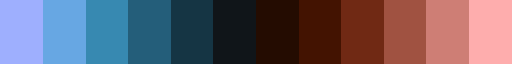

In [15]:
peak_cmap = plt.get_cmap('berlin', runner_cfg.MODEL.N_LAYERS)
peak_cmap

In [16]:
import numpy as np

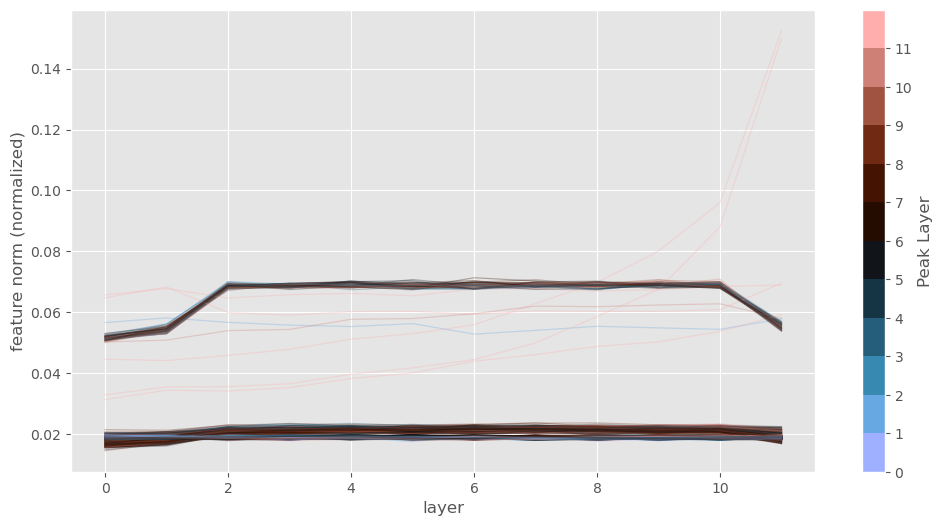

In [17]:
plt.style.use('ggplot')

decoder_norm = model.W_dec.norm(dim=-1)[:1000]
peaks = decoder_norm.max(-1)
peak_layers = peaks.indices.detach().cpu().numpy()
# decoder_norm = decoder_norm / peaks.values.unsqueeze(1)
# decoder_norm = decoder_norm.T
decoder_norm = decoder_norm.detach().cpu().numpy()

# mask = decoder_norm[:,0] < 0.9
mask = np.ones(decoder_norm.shape[0], dtype=bool)

decoder_norm = decoder_norm[mask]
peak_layers = peak_layers[mask]



for i in range(decoder_norm.shape[0]):
    plt.plot(decoder_norm[i], alpha=0.3, linewidth=0.9, color=peak_cmap(peak_layers[i]))




cbar = plt.colorbar(plt.cm.ScalarMappable(cmap=peak_cmap, norm=plt.Normalize(vmin=0, vmax=12)), ax=plt.gca())
cbar.set_label('Peak Layer')
cbar.set_ticks(range(runner_cfg.MODEL.N_LAYERS))

# plt.gca().set_ylim(0.95, 1.01)
plt.gca().set_xlabel('layer')
plt.gca().set_ylabel('feature norm (normalized)')
plt.gcf().set_size_inches(12, 6)

In [33]:
x = model.W_dec


x_normalized = x / (x.norm(dim=-1, keepdim=True) + 1e-8)
cosine_similarity = x_normalized @ x_normalized.transpose(-2, -1)
cosine_similarity

tensor([[[ 1.0000e+00, -2.3771e-02, -4.2231e-02,  ..., -7.4300e-03,
           3.0629e-02,  1.1728e-02],
         [-2.3771e-02,  1.0000e+00,  2.9015e-02,  ..., -3.7054e-02,
           6.1784e-03, -4.8710e-02],
         [-4.2231e-02,  2.9015e-02,  1.0000e+00,  ...,  4.8309e-02,
           6.0577e-03,  5.7515e-03],
         ...,
         [-7.4300e-03, -3.7054e-02,  4.8309e-02,  ...,  1.0000e+00,
          -2.1045e-02,  2.7484e-03],
         [ 3.0629e-02,  6.1784e-03,  6.0577e-03,  ..., -2.1045e-02,
           1.0000e+00, -2.5594e-02],
         [ 1.1728e-02, -4.8710e-02,  5.7515e-03,  ...,  2.7484e-03,
          -2.5594e-02,  1.0000e+00]],

        [[ 1.0000e+00,  2.6068e-02,  3.8540e-02,  ...,  4.3638e-02,
          -1.7976e-02,  2.9346e-02],
         [ 2.6068e-02,  1.0000e+00,  1.8578e-02,  ...,  2.7945e-02,
           4.3966e-02,  2.3978e-02],
         [ 3.8540e-02,  1.8578e-02,  1.0000e+00,  ...,  7.9276e-04,
           8.8000e-03, -1.1812e-02],
         ...,
         [ 4.3638e-02,  2

In [34]:
cossim = cosine_similarity[:10].detach().cpu().numpy()
plt.style.use('default')

Text(0.5, 0, 'layer')

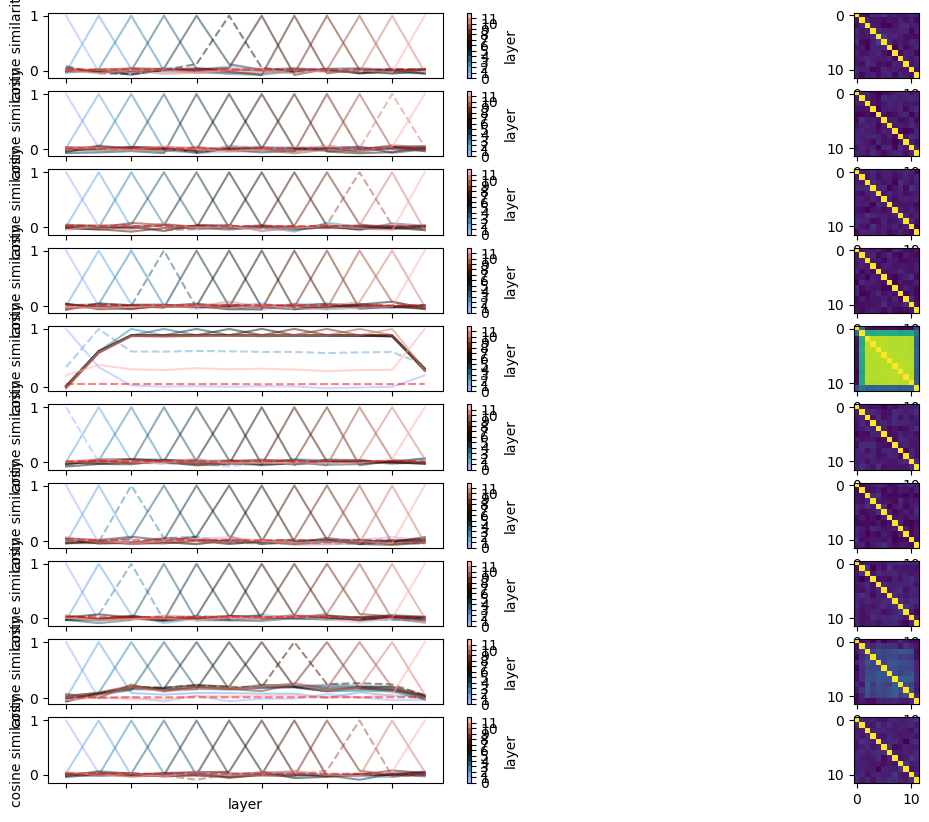

In [35]:
fig, ax = plt.subplots(nrows=len(cossim), ncols=2, figsize=(14, 10))


for i in range(len(ax)):

    for j in range(cossim.shape[1]):
        ax[i][0].plot(cossim[i][j], color=peak_cmap(j), alpha=0.5, linestyle='dashed' if j == peak_layers[i] else 'solid')

    ax[i][0].plot(decoder_norm[i], color='red', alpha=0.5, linestyle='dashed')


    cbar = plt.colorbar(plt.cm.ScalarMappable(cmap=peak_cmap, norm=plt.Normalize(vmin=0, vmax=12)), ax=ax[i][0])
    cbar.set_label('layer')
    cbar.set_ticks(range(runner_cfg.MODEL.N_LAYERS))

    ax[i][0].set_ylabel('cosine similarity')
    ax[i][0].set_xticklabels([])


    ax[i][1].imshow(cossim[i])

    # ax[i][0].set_ylim(-0.15, 0.15)



ax[i][0].set_xlabel('layer')

In [38]:
x = batch['resid_post']
x_hat = model(x)

In [39]:
from crosscoders.autoencoders.acausal.loss import AcausalLossJumpReLU


AcausalLossJumpReLU(runner_cfg.LOSS)(x, x_hat, model.x_enc, model.W_dec, model.t)

(tensor(87059.3594, device='cuda:0', grad_fn=<AddBackward0>),
 LossMetrics(
     loss = 87059.359375,
     error = 85765.609375,
     l1 = 129.37374877929688,
     lp = 4490.60400390625,
     l0 = 152.1865234375,
     explained_variance = 0.7958527207374573,
     dead_neurons = DeadNeuronMetrics(
         all_tokens = 0.0008544921875,
         one_token = 0.55718994140625,
         no_token = 0.44281005859375,
     ),
 ))

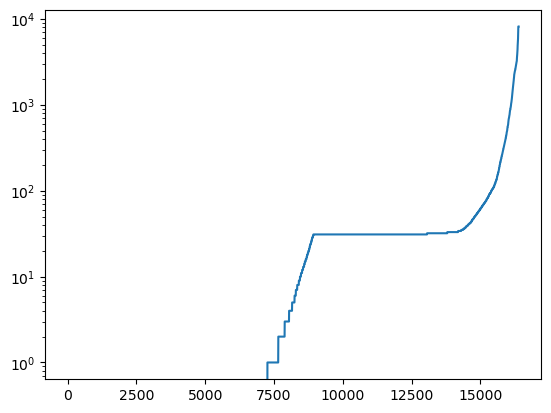

In [46]:
x = (model.x_enc > 0).sum(0).detach().cpu().numpy()
x = sorted(x)

plt.plot(x)
plt.yscale('log')

In [49]:
x = model.x_enc.detach().cpu().numpy()

mask = x > 0

In [55]:
import datasets


hf_dataset = datasets.load_dataset('roneneldan/TinyStories', streaming=True)
ds = ray.data.from_huggingface(hf_dataset['train'], concurrency=1)

# tokens_dl =
text = ds.take_batch(8192)['text']

2025-02-19 02:54:15,944	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2025-02-19_00-59-16_117430_16444/logs/ray-data
2025-02-19 02:54:15,945	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadHuggingFace] -> LimitOperator[limit=8192]


Running 0: 0.00 row [00:00, ? row/s]

- ReadHuggingFace->SplitBlocks(14) 1: 0.00 row [00:00, ? row/s]

- limit=8192 2: 0.00 row [00:00, ? row/s]

In [48]:
from sae_lens import HookedSAETransformer


gpt2 = HookedSAETransformer.from_pretrained('gpt2-small')

Loaded pretrained model gpt2-small into HookedTransformer


In [56]:
tokens = gpt2.to_tokens(text)
tokens.shape

torch.Size([8192, 1024])

In [67]:
W_emb = next(gpt2.embed.parameters())

In [75]:
mask = (model.W_dec.norm(dim=-1).min(-1).values > 0.03)

In [155]:
import einops


W_emb.shape, model.W_dec.shape

feature_to_token = einops.einsum(
    W_emb, model.W_dec[mask],
    'vocab d_model , d_coder n_layers d_model ->  d_coder n_layers vocab'
)
# feature_to_token = feature_to_token.detach().cpu().numpy()
feature_to_token.shape

torch.Size([760, 12, 50257])

In [106]:
feature_to_token = (feature_to_token - feature_to_token.min((1, 2))[:, None, None]) / (feature_to_token.max((1, 2))[:, None, None] - feature_to_token.min((1, 2))[:, None, None])
feature_to_token
feature_to_token.shape

(760, 12, 50257)

0.0 1.0


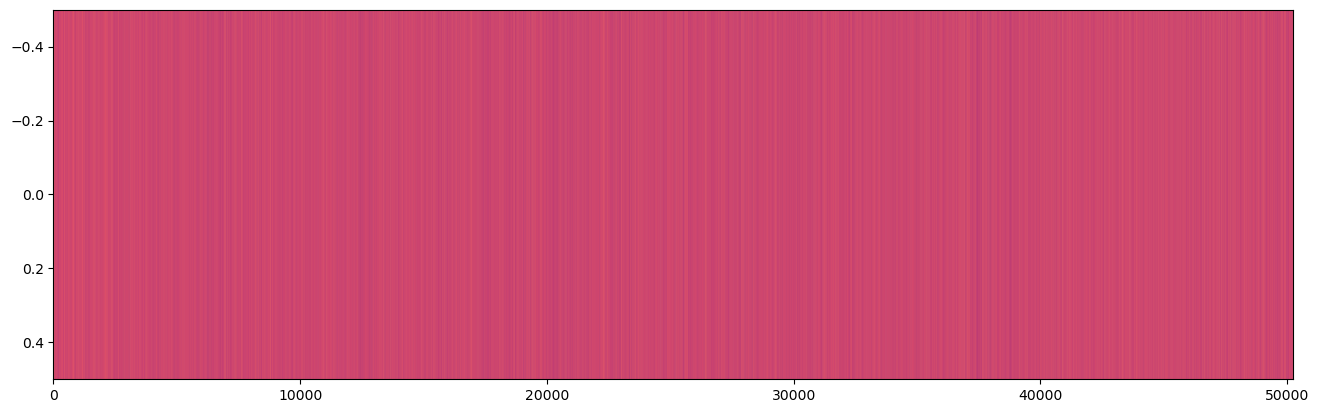

In [113]:
i = 2
print(feature_to_token[i].min(), feature_to_token[i].max())
plt.imshow(feature_to_token[i][:1], aspect='auto', vmin=feature_to_token[i].min(), vmax=feature_to_token[i].max(), cmap='magma')
plt.gcf().set_figwidth(16)

# PICK UP HERE
seems like looking at decoder @ embed shows more interesting patterns in rotations across layers

In [178]:
i = 10
x = feature_to_token[10:20]
# x = x + 1 - x.max(-1)[:, None]

x_normalized = x / (x.norm(dim=-1, keepdim=True) + 1e-8)
cosine_similarity = x_normalized @ x_normalized.transpose(-2, -1)
# cosine_similarity = x_normalized @ x_normalized.T
# cosine_similarity = (cosine_similarity - cosine_similarity.min(-1)[None,:]) / (cosine_similarity.max(-1)[None,:] - cosine_similarity.min(-1)[None,:])
cosine_similarity = cosine_similarity.detach().cpu().numpy()
cosine_similarity.shape

# plt.plot(cosine_similarity)
# plt.show()

(10, 12, 12)

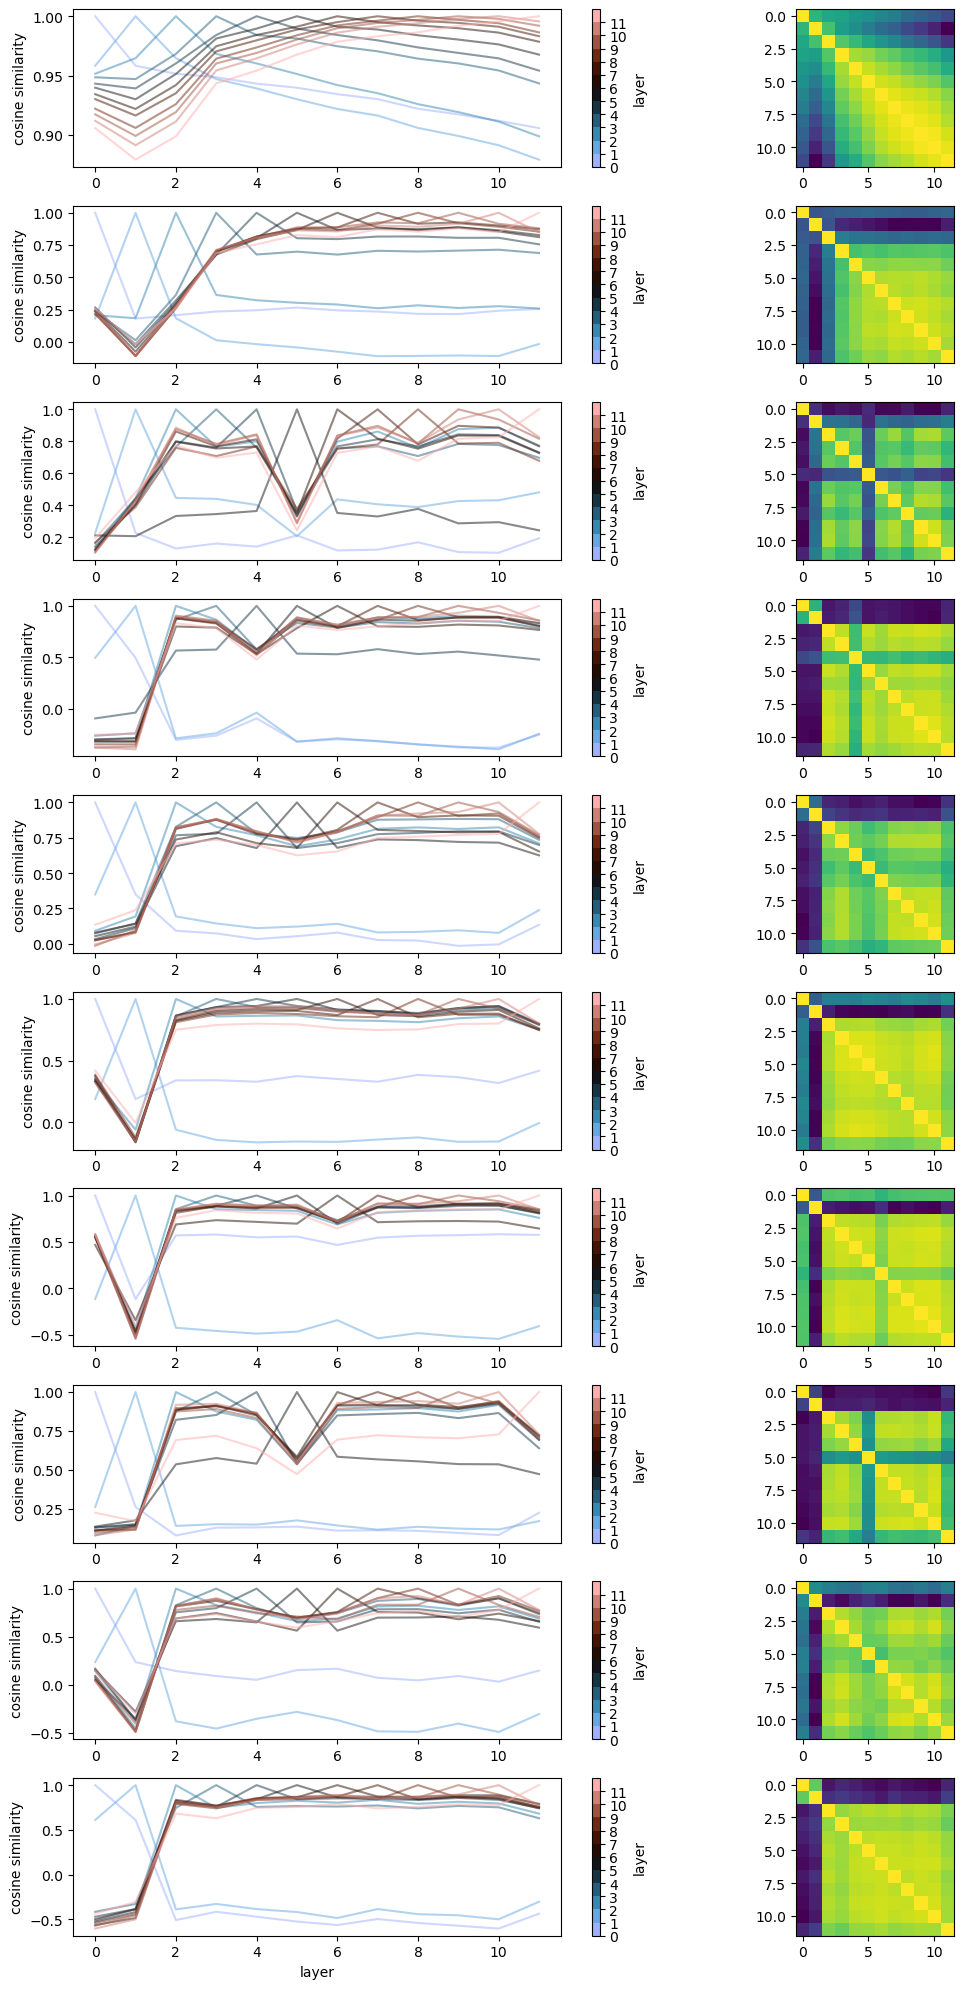

In [179]:
fig, ax = plt.subplots(nrows=len(cosine_similarity), ncols=2, figsize=(12, 20))


for i in range(len(ax)):

    for j in range(cosine_similarity.shape[1]):
        ax[i][0].plot(cosine_similarity[i][j], color=peak_cmap(j), alpha=0.5) #, linestyle='dashed' if j == peak_layers[i] else 'solid')

    # ax[i][0].plot(decoder_norm[i], color='red', alpha=0.5, linestyle='dashed')


    cbar = plt.colorbar(plt.cm.ScalarMappable(cmap=peak_cmap, norm=plt.Normalize(vmin=0, vmax=12)), ax=ax[i][0])
    cbar.set_label('layer')
    cbar.set_ticks(range(runner_cfg.MODEL.N_LAYERS))

    ax[i][0].set_ylabel('cosine similarity')
    # ax[i][0].set_xticklabels([])


    ax[i][1].imshow(cosine_similarity[i], aspect='equal')

    # ax[i][0].set_ylim(-0.15, 0.15)



ax[i][0].set_xlabel('layer')


plt.tight_layout()